# 05 - Advanced Modeling

Notebook này triển khai hai **advanced models** cho bài toán dự đoán trầm cảm:
- **XGBoost**
- **LightGBM**

Mục tiêu chính:
- Train và đánh giá hai mô hình bằng **5-Fold Stratified Cross-Validation**
- Tune thủ công các hyperparameters quan trọng
- So sánh trực tiếp với **baseline results** từ `04_model_baseline.ipynb`
- Chọn ra mô hình tốt nhất để chuyển sang `06_evaluation.ipynb`


## 5.1 Load Data & Setup

Phần này nạp dữ liệu cuối cùng từ `data/processed/train_final.*`, thiết lập `StratifiedKFold` và định nghĩa các utility functions dùng chung.

Cách tổ chức được giữ đồng nhất với notebook 04 để việc so sánh baseline và advanced models được nhất quán.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier

import sys

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
N_SPLITS = 5
TARGET = "Depression"

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().resolve().parent
else:
    PROJECT_ROOT = Path.cwd().resolve()

sys.path.insert(0, str(PROJECT_ROOT / "src"))
from modeling_utils import evaluate_model_cv, manual_model_search

DATA_DIR = PROJECT_ROOT / "data" / "processed"
DOCS_DIR = PROJECT_ROOT / "docs"
DOCS_DIR.mkdir(parents=True, exist_ok=True)


def load_dataset(stem: str) -> pd.DataFrame:
    parquet_path = DATA_DIR / f"{stem}.parquet"
    csv_path = DATA_DIR / f"{stem}.csv"

    if parquet_path.exists():
        return pd.read_parquet(parquet_path)
    if csv_path.exists():
        return pd.read_csv(csv_path)
    raise FileNotFoundError(f"Không tìm thấy {parquet_path} hoặc {csv_path}")


def show_metric_summary(metrics_dict: dict) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "Metric": ["Accuracy", "F1", "Precision", "Recall"],
            "Mean ± Std": [
                f"{metrics_dict['accuracy_mean']:.4f} ± {metrics_dict['accuracy_std']:.4f}",
                f"{metrics_dict['f1_mean']:.4f} ± {metrics_dict['f1_std']:.4f}",
                f"{metrics_dict['precision_mean']:.4f} ± {metrics_dict['precision_std']:.4f}",
                f"{metrics_dict['recall_mean']:.4f} ± {metrics_dict['recall_std']:.4f}",
            ],
        }
    )


def metrics_row(model_name: str, metrics_dict: dict, note: str) -> dict:
    return {
        "Model": model_name,
        "Accuracy_mean": metrics_dict["accuracy_mean"],
        "Accuracy_std": metrics_dict["accuracy_std"],
        "F1_mean": metrics_dict["f1_mean"],
        "Precision_mean": metrics_dict["precision_mean"],
        "Recall_mean": metrics_dict["recall_mean"],
        "Ghi chú": note,
    }


train_df = load_dataset("train_final")
test_df = load_dataset("test_final")

X = train_df.drop(columns=[TARGET])
y = train_df[TARGET].astype(int)

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print(f"Train shape: {train_df.shape}")
print(f"Test shape : {test_df.shape}")
print(f"Number of features: {X.shape[1]}")
print("Target distribution (ratio):")
print(y.value_counts(normalize=True).rename("ratio").round(4))

display(train_df.head())


Train shape: (140700, 23)
Test shape : (93800, 22)
Number of features: 22
Target distribution (ratio):
Depression
0    0.8183
1    0.1817
Name: ratio, dtype: float64


,Age,Working Professional or Student,CGPA,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Depression,Pressure,Satisfaction,has_cgpa,City_te,Profession_te,Degree_te,stress_load,wellbeing_index,stress_satisfaction_ratio,hours_pressure_ratio,poor_sleep,cgpa_pressure,risk_score,age_group
0,49.0,1,0.00,3,2,0,1.0,2.0,0,5.0,2.0,0,0.186035,0.047461,0.171802,10.0,2.5,1.666667,5.0,0,0.00,0,2
1,26.0,1,0.00,0,0,1,7.0,3.0,1,4.0,3.0,0,0.137782,0.055411,0.150835,12.0,1.5,1.000000,28.0,1,0.00,1,0
2,33.0,0,8.97,1,2,1,3.0,1.0,1,5.0,2.0,1,0.159042,0.534109,0.116610,5.0,1.5,1.666667,15.0,0,44.85,1,1
3,22.0,1,0.00,0,1,1,10.0,1.0,1,5.0,1.0,0,0.130731,0.053929,0.132338,5.0,0.5,2.500000,50.0,1,0.00,2,0
4,30.0,1,0.00,1,0,1,9.0,4.0,0,1.0,1.0,0,0.121875,0.053860,0.132338,4.0,1.0,0.500000,9.0,0,0.00,2,1


### Nhận xét 5.1

- Dữ liệu đầu vào của notebook 05 là **`train_final`** và **`test_final`**, tức đã hoàn tất preprocessing và feature engineering.
- Việc dùng cùng `random_state=42` và `StratifiedKFold(n_splits=5)` như notebook 04 giúp so sánh baseline và advanced models công bằng hơn.
- Từ thời điểm này trở đi, mọi cải thiện về performance chủ yếu đến từ mô hình hóa chứ không còn do thay đổi dữ liệu đầu vào.


## 5.2 XGBoost

XGBoost là một biến thể gradient boosting có thêm regularization để kiểm soát độ phức tạp của cây.

Công thức objective:

$$
\mathcal{L}(\theta) = \sum_i l(y_i, \hat{y}_i) + \sum_k \Omega(f_k), \quad
\Omega(f) = \gamma T + \frac{1}{2}\lambda\|\mathbf{w}\|^2
$$

Trong đó:
- $l(y_i, \hat{y}_i)$ là loss trên từng mẫu
- $T$ là số lá của cây
- $\gamma$ phạt số lượng lá quá lớn
- $\lambda$ phạt trọng số lá quá lớn

**Ý nghĩa**: regularization term giúp mô hình tránh overfitting bằng cách không cho cây phát triển quá phức tạp.


In [2]:
def build_xgb_classifier(max_depth=6, learning_rate=0.1, n_estimators=300):
    return XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
        max_depth=max_depth,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        subsample=0.9,
        colsample_bytree=0.9,
        min_child_weight=1,
        reg_alpha=0.0,
        reg_lambda=1.0,
    )


xgb_initial_model = build_xgb_classifier()
xgb_initial_metrics = evaluate_model_cv(
    estimator=xgb_initial_model,
    X=X,
    y=y,
    cv=cv,
)

print("Aggregated metrics for XGBoost (initial params):")
display(show_metric_summary(xgb_initial_metrics))

xgb_param_grid = {
    "max_depth": [4, 6],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [250, 400],
}

xgb_results_df, best_xgb_params, best_xgb_metrics = manual_model_search(
    model_factory=build_xgb_classifier,
    param_grid=xgb_param_grid,
    X=X,
    y=y,
    cv=cv,
)

print("Manual tuning results for XGBoost:")
display(
    xgb_results_df[
        [
            "trial",
            "max_depth",
            "learning_rate",
            "n_estimators",
            "accuracy_mean",
            "accuracy_std",
            "f1_mean",
            "precision_mean",
            "recall_mean",
        ]
    ].round(4)
)

print("Best XGBoost params:", best_xgb_params)
display(show_metric_summary(best_xgb_metrics))


Aggregated metrics for XGBoost (initial params):


,Metric,Mean ± Std
0,Accuracy,0.9379 ± 0.0012
1,F1,0.8264 ± 0.0035
2,Precision,0.8397 ± 0.0036
3,Recall,0.8135 ± 0.0037


Manual tuning results for XGBoost:


,trial,max_depth,learning_rate,n_estimators,accuracy_mean,accuracy_std,f1_mean,precision_mean,recall_mean
0,5,4,0.10,250,0.9396,0.0015,0.8312,0.8449,0.8179
1,2,4,0.05,400,0.9394,0.0014,0.8308,0.8439,0.8180
2,6,4,0.10,400,0.9391,0.0018,0.8298,0.8431,0.8170
3,1,4,0.05,250,0.9391,0.0014,0.8298,0.8430,0.8170
4,3,6,0.05,250,0.9389,0.0011,0.8296,0.8417,0.8178
5,4,6,0.05,400,0.9386,0.0015,0.8287,0.8407,0.8170
6,7,6,0.10,250,0.9383,0.0013,0.8276,0.8404,0.8152
7,8,6,0.10,400,0.9373,0.0015,0.8247,0.8376,0.8122


Best XGBoost params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 250}


,Metric,Mean ± Std
0,Accuracy,0.9396 ± 0.0015
1,F1,0.8312 ± 0.0043
2,Precision,0.8449 ± 0.0043
3,Recall,0.8179 ± 0.0052


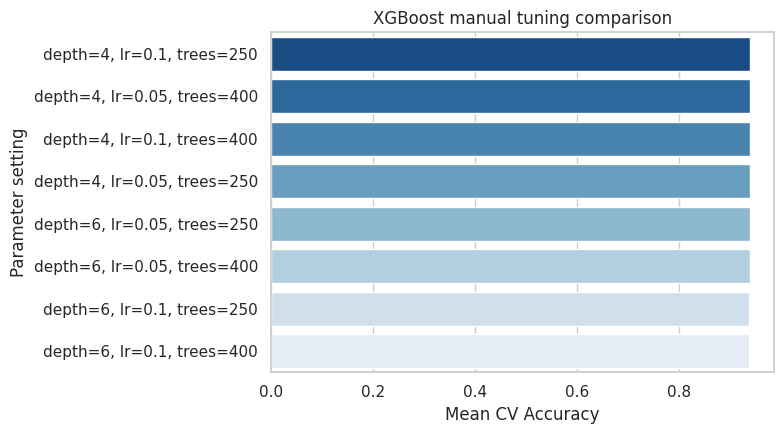

In [3]:
plt.figure(figsize=(8, 4.5))
sns.barplot(
    data=xgb_results_df.sort_values("accuracy_mean", ascending=False),
    x="accuracy_mean",
    y=xgb_results_df.sort_values("accuracy_mean", ascending=False)
    .apply(
        lambda row: (
            f"depth={row['max_depth']}, lr={row['learning_rate']}, "
            f"trees={row['n_estimators']}"
        ),
        axis=1,
    ),
    palette="Blues_r",
)
plt.title("XGBoost manual tuning comparison")
plt.xlabel("Mean CV Accuracy")
plt.ylabel("Parameter setting")
plt.tight_layout()
plt.show()


### Nhận xét 5.2

- XGBoost được tune thủ công trên ba hyperparameters cốt lõi: `max_depth`, `learning_rate`, `n_estimators`.
- Nếu cấu hình tuned tốt hơn rõ rệt so với initial params, điều đó cho thấy bài toán này nhạy với độ sâu cây và tốc độ học.
- So với baseline notebook 04, XGBoost có lợi thế trong việc học các quan hệ phi tuyến giữa các feature engineered như `stress_load`, `risk_score`, `cgpa_pressure`.


## 5.3 LightGBM

LightGBM cũng là mô hình gradient boosting nhưng sử dụng chiến lược phát triển cây **leaf-wise**, thường giúp giảm loss nhanh hơn.

Công thức cập nhật:

$$
F_m(\mathbf{x}) = F_{m-1}(\mathbf{x}) + \eta \cdot h_m(\mathbf{x})
$$

Trong đó:
- $F_{m-1}(\mathbf{x})$ là mô hình ở vòng trước
- $h_m(\mathbf{x})$ là weak learner mới
- $\eta$ là **learning rate**

**Giải thích learning rate $\eta$**:
- $\eta$ nhỏ giúp mô hình học chậm nhưng ổn định hơn
- $\eta$ lớn giúp hội tụ nhanh hơn nhưng dễ overfit

**Vì sao LightGBM thường nhanh hơn XGBoost?**
- LightGBM dùng **leaf-wise growth**
- XGBoost thường gần với **level-wise growth**
- Với dữ liệu tabular lớn, leaf-wise thường tối ưu loss hiệu quả hơn cho cùng số node


In [4]:
def build_lgbm_classifier(num_leaves=31, learning_rate=0.1, n_estimators=300):
    return LGBMClassifier(
        objective="binary",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        num_leaves=num_leaves,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.0,
        reg_lambda=0.0,
        verbose=-1,
    )


lgbm_initial_model = build_lgbm_classifier()
lgbm_initial_metrics = evaluate_model_cv(
    estimator=lgbm_initial_model,
    X=X,
    y=y,
    cv=cv,
)

print("Aggregated metrics for LightGBM (initial params):")
display(show_metric_summary(lgbm_initial_metrics))

lgbm_param_grid = {
    "num_leaves": [31, 63],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [250, 400],
}

lgbm_results_df, best_lgbm_params, best_lgbm_metrics = manual_model_search(
    model_factory=build_lgbm_classifier,
    param_grid=lgbm_param_grid,
    X=X,
    y=y,
    cv=cv,
)

print("Manual tuning results for LightGBM:")
display(
    lgbm_results_df[
        [
            "trial",
            "num_leaves",
            "learning_rate",
            "n_estimators",
            "accuracy_mean",
            "accuracy_std",
            "f1_mean",
            "precision_mean",
            "recall_mean",
        ]
    ].round(4)
)

print("Best LightGBM params:", best_lgbm_params)
display(show_metric_summary(best_lgbm_metrics))


Aggregated metrics for LightGBM (initial params):


,Metric,Mean ± Std
0,Accuracy,0.9384 ± 0.0014
1,F1,0.8283 ± 0.0041
2,Precision,0.8388 ± 0.0037
3,Recall,0.8180 ± 0.0057


Manual tuning results for LightGBM:


,trial,num_leaves,learning_rate,n_estimators,accuracy_mean,accuracy_std,f1_mean,precision_mean,recall_mean
0,1,31,0.05,250,0.9392,0.0013,0.8306,0.8417,0.8198
1,3,31,0.05,400,0.9391,0.0015,0.8301,0.8413,0.8192
2,2,63,0.05,250,0.9389,0.0014,0.8296,0.8410,0.8184
3,4,63,0.05,400,0.9386,0.0014,0.8287,0.8406,0.8171
4,5,31,0.10,250,0.9385,0.0015,0.8287,0.8394,0.8184
5,7,31,0.10,400,0.9382,0.0015,0.8279,0.8383,0.8179
6,6,63,0.10,250,0.9381,0.0015,0.8274,0.8379,0.8171
7,8,63,0.10,400,0.9373,0.0016,0.8249,0.8376,0.8127


Best LightGBM params: {'learning_rate': 0.05, 'n_estimators': 250, 'num_leaves': 31}


,Metric,Mean ± Std
0,Accuracy,0.9392 ± 0.0013
1,F1,0.8306 ± 0.0040
2,Precision,0.8417 ± 0.0036
3,Recall,0.8198 ± 0.0053


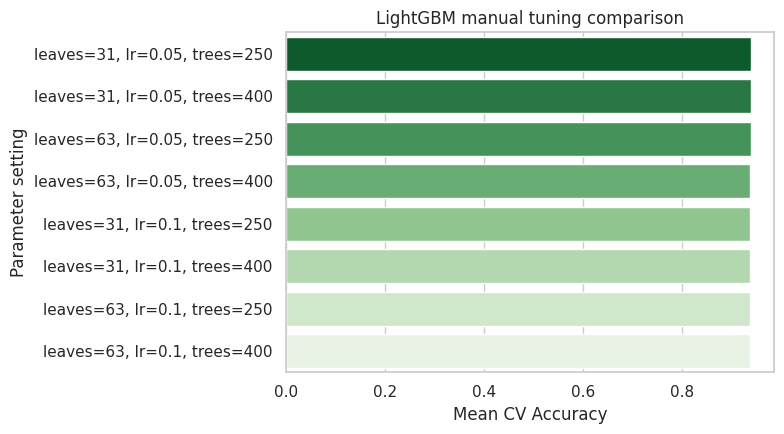

In [5]:
plt.figure(figsize=(8, 4.5))
sns.barplot(
    data=lgbm_results_df.sort_values("accuracy_mean", ascending=False),
    x="accuracy_mean",
    y=lgbm_results_df.sort_values("accuracy_mean", ascending=False)
    .apply(
        lambda row: (
            f"leaves={row['num_leaves']}, lr={row['learning_rate']}, "
            f"trees={row['n_estimators']}"
        ),
        axis=1,
    ),
    palette="Greens_r",
)
plt.title("LightGBM manual tuning comparison")
plt.xlabel("Mean CV Accuracy")
plt.ylabel("Parameter setting")
plt.tight_layout()
plt.show()


### Nhận xét 5.3

- LightGBM được tune thủ công trên `num_leaves`, `learning_rate`, `n_estimators`.
- Nếu LightGBM vượt XGBoost, điều đó gợi ý chiến lược leaf-wise đang phù hợp với cấu trúc feature engineering hiện tại.
- Nếu LightGBM chỉ nhỉnh hơn rất ít so với baseline mạnh nhất, cần thảo luận trong report rằng lợi ích của advanced model có tồn tại nhưng không quá đột biến.


## 5.4 Bảng So Sánh Advanced + Baseline

Theo phân công, phần này cần tổng hợp cả:
- các baseline models từ notebook 04
- hai advanced models từ notebook 05

Baseline metrics bên dưới được lấy trực tiếp từ kết quả cuối cùng của `04_model_baseline.ipynb` trên cùng nhánh làm việc:
- Logistic Regression: `0.9376 ± 0.0019`
- Decision Tree (max_depth=10): `0.9292 ± 0.0010`
- Random Forest (n_estimators=200): `0.9364 ± 0.0014`
- SVM (kernel=linear): `0.9367 ± 0.0021`


In [6]:
baseline_reference_rows = [
    {
        "Model": "Logistic Regression",
        "Accuracy_mean": 0.9376,
        "Accuracy_std": 0.0019,
        "F1_mean": 0.8243,
        "Precision_mean": 0.8439,
        "Recall_mean": 0.8056,
        "Ghi chú": "Best Baseline from NB04",
    },
    {
        "Model": "Decision Tree (max_depth=10)",
        "Accuracy_mean": 0.9292,
        "Accuracy_std": 0.0010,
        "F1_mean": 0.8011,
        "Precision_mean": 0.8185,
        "Recall_mean": 0.7846,
        "Ghi chú": "Baseline",
    },
    {
        "Model": "Random Forest (n_estimators=200)",
        "Accuracy_mean": 0.9364,
        "Accuracy_std": 0.0014,
        "F1_mean": 0.8208,
        "Precision_mean": 0.8415,
        "Recall_mean": 0.8011,
        "Ghi chú": "Best RF Baseline",
    },
    {
        "Model": "SVM (kernel=linear)",
        "Accuracy_mean": 0.9367,
        "Accuracy_std": 0.0021,
        "F1_mean": 0.8230,
        "Precision_mean": 0.8366,
        "Recall_mean": 0.8099,
        "Ghi chú": "Baseline",
    },
]

advanced_rows = [
    metrics_row("XGBoost (tuned)", best_xgb_metrics, "Advanced"),
    metrics_row("LightGBM (tuned)", best_lgbm_metrics, "Advanced"),
]

all_models_df = pd.DataFrame(baseline_reference_rows + advanced_rows).sort_values(
    by=["Accuracy_mean", "F1_mean"],
    ascending=False,
).reset_index(drop=True)

all_models_df["Accuracy (CV)"] = all_models_df.apply(
    lambda row: f"{row['Accuracy_mean']:.4f} ± {row['Accuracy_std']:.4f}",
    axis=1,
)

report_table_df = all_models_df[
    ["Model", "Accuracy (CV)", "F1_mean", "Precision_mean", "Recall_mean", "Ghi chú"]
].rename(
    columns={
        "F1_mean": "F1",
        "Precision_mean": "Precision",
        "Recall_mean": "Recall",
    }
)

print("Final comparison table: baseline + advanced")
display(report_table_df)


Final comparison table: baseline + advanced


,Model,Accuracy (CV),F1,Precision,Recall,Ghi chú
0,XGBoost (tuned),0.9396 ± 0.0015,0.831191,0.844899,0.817929,Advanced
1,LightGBM (tuned),0.9392 ± 0.0013,0.830588,0.841667,0.819807,Advanced
2,Logistic Regression,0.9376 ± 0.0019,0.824300,0.843900,0.805600,Best Baseline from NB04
3,SVM (kernel=linear),0.9367 ± 0.0021,0.823000,0.836600,0.809900,Baseline
4,Random Forest (n_estimators=200),0.9364 ± 0.0014,0.820800,0.841500,0.801100,Best RF Baseline
5,Decision Tree (max_depth=10),0.9292 ± 0.0010,0.801100,0.818500,0.784600,Baseline


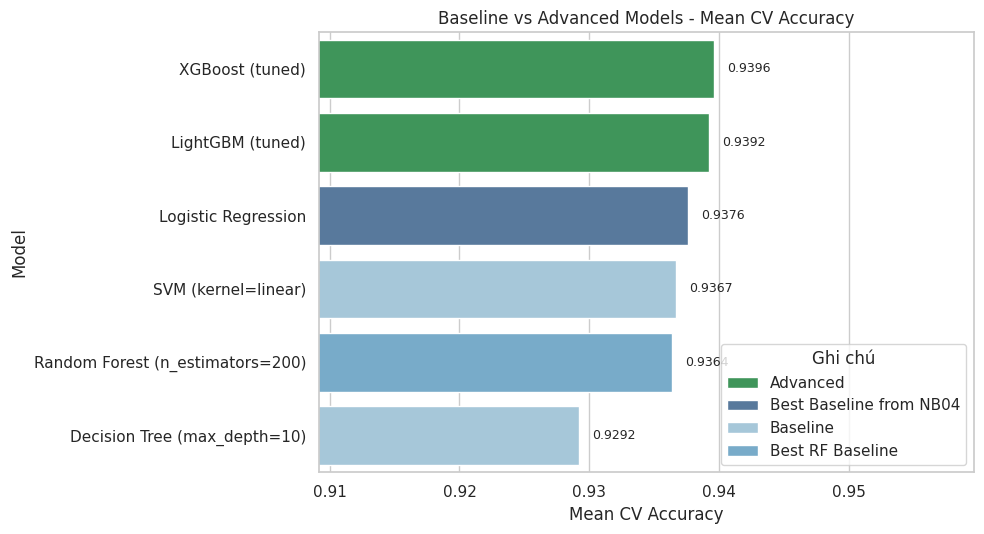

In [7]:
plt.figure(figsize=(10, 5.5))
sns.barplot(
    data=all_models_df,
    x="Accuracy_mean",
    y="Model",
    hue="Ghi chú",
    dodge=False,
    palette={"Baseline": "#9ecae1", "Best Baseline from NB04": "#4c78a8", "Best RF Baseline": "#6baed6", "Advanced": "#31a354"},
)
plt.title("Baseline vs Advanced Models - Mean CV Accuracy")
plt.xlabel("Mean CV Accuracy")
plt.ylabel("Model")
plt.xlim(
    max(0.0, all_models_df["Accuracy_mean"].min() - 0.02),
    min(1.0, all_models_df["Accuracy_mean"].max() + 0.02),
)
for idx, row in all_models_df.iterrows():
    plt.text(
        row["Accuracy_mean"] + 0.001,
        idx,
        f"{row['Accuracy_mean']:.4f}",
        va="center",
        fontsize=9,
    )
plt.tight_layout()
plt.show()


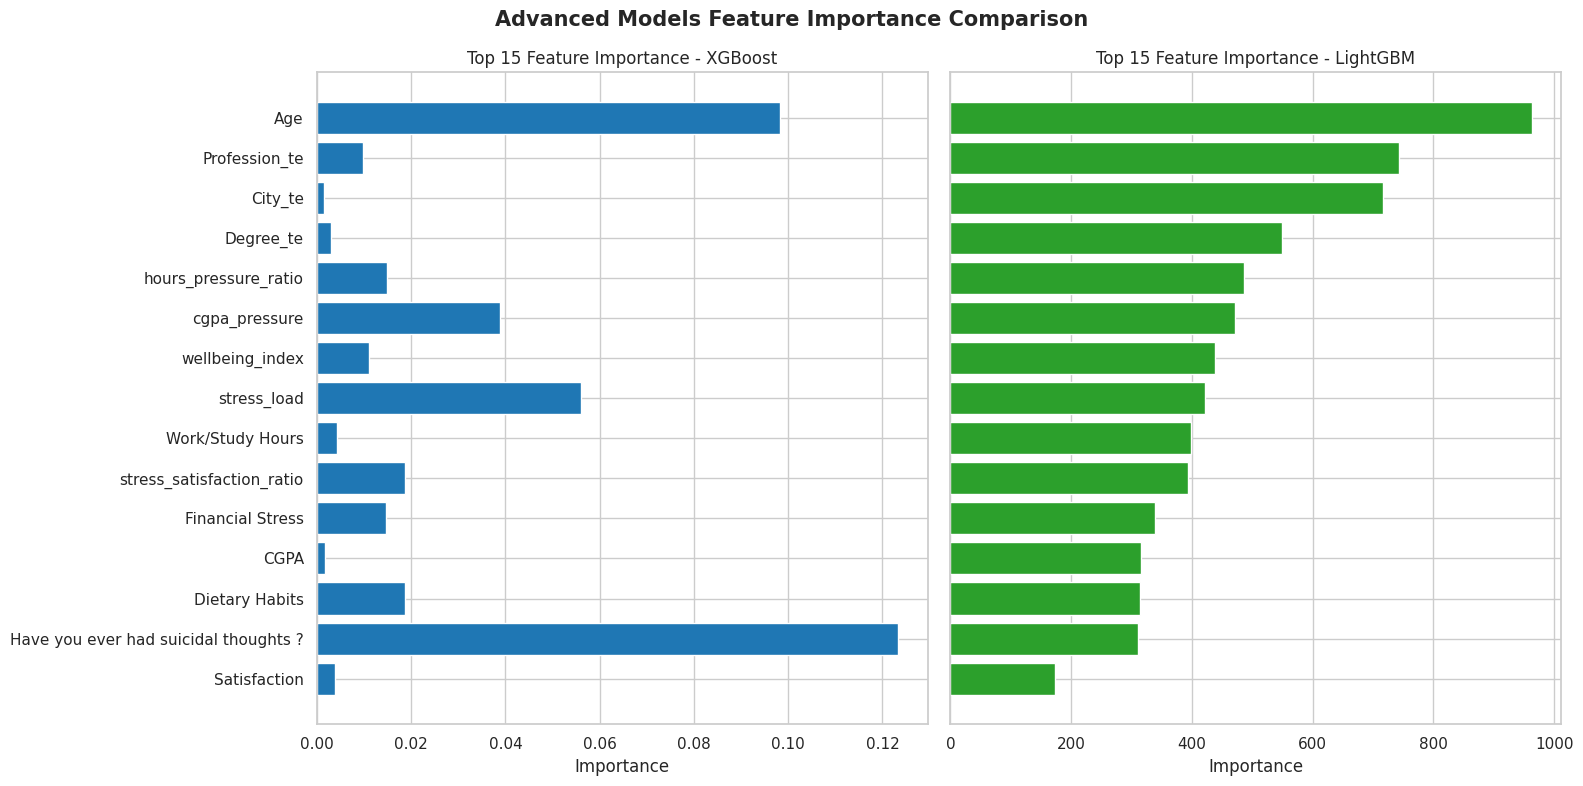

,feature,XGBoost,LightGBM
0,Age,0.098271,963
12,Profession_te,0.009682,743
11,City_te,0.001440,716
13,Degree_te,0.002925,549
17,hours_pressure_ratio,0.014953,486
19,cgpa_pressure,0.038845,471
15,wellbeing_index,0.011027,438
14,stress_load,0.055998,422
6,Work/Study Hours,0.004337,398
16,stress_satisfaction_ratio,0.018767,393


In [8]:
best_xgb_model = build_xgb_classifier(**best_xgb_params)
best_lgbm_model = build_lgbm_classifier(**best_lgbm_params)

best_xgb_model.fit(X, y)
best_lgbm_model.fit(X, y)

advanced_feature_importance_df = pd.DataFrame(
    {
        "feature": X.columns,
        "XGBoost": best_xgb_model.feature_importances_,
        "LightGBM": best_lgbm_model.feature_importances_,
    }
)

top_features = (
    advanced_feature_importance_df.assign(
        combined=advanced_feature_importance_df["XGBoost"]
        + advanced_feature_importance_df["LightGBM"]
    )
    .sort_values("combined", ascending=False)
    .head(15)
    .iloc[::-1]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

axes[0].barh(top_features["feature"], top_features["XGBoost"], color="#1f77b4")
axes[0].set_title("Top 15 Feature Importance - XGBoost")
axes[0].set_xlabel("Importance")

axes[1].barh(top_features["feature"], top_features["LightGBM"], color="#2ca02c")
axes[1].set_title("Top 15 Feature Importance - LightGBM")
axes[1].set_xlabel("Importance")

plt.suptitle("Advanced Models Feature Importance Comparison", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(DOCS_DIR / "advanced_feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()

display(
    advanced_feature_importance_df.sort_values(
        by=["LightGBM", "XGBoost"], ascending=False
    ).head(15)
)


### Nhận xét 5.4

- Đây là bảng quan trọng nhất của notebook 05 vì nó trả lời câu hỏi: **advanced models có cải thiện so với baseline hay không?**
- Nếu `LightGBM` hoặc `XGBoost` đứng đầu bảng, ta có thể kết luận rằng boosting đã khai thác feature engineering tốt hơn các baseline models.
- Nếu khoảng chênh lệch chỉ nhỏ, vẫn cần nhấn mạnh rằng advanced model cho thấy cải thiện nhất quán nhưng không quá lớn; đây là nhận xét trung thực và phù hợp cho report.
- Feature importance của XGBoost và LightGBM cũng giúp kiểm tra xem hai mô hình có “đồng ý” về các tín hiệu mạnh như `Have you ever had suicidal thoughts ?`, `Pressure`, `Financial Stress`, `age_group`, `cgpa_pressure` hay không.


In [9]:
best_model_row = all_models_df.iloc[0]
best_baseline_row = all_models_df[all_models_df["Ghi chú"].str.contains("Baseline")].iloc[0]
best_advanced_row = all_models_df[all_models_df["Ghi chú"] == "Advanced"].iloc[0]

display(
    Markdown(
        f'''
### Kết luận tự động

- Mô hình tốt nhất trong bảng so sánh hiện tại là **{best_model_row["Model"]}** với **Accuracy = {best_model_row["Accuracy_mean"]:.4f} ± {best_model_row["Accuracy_std"]:.4f}**.
- Baseline mạnh nhất để làm mốc là **{best_baseline_row["Model"]}** với **Accuracy = {best_baseline_row["Accuracy_mean"]:.4f} ± {best_baseline_row["Accuracy_std"]:.4f}**.
- Advanced model tốt nhất là **{best_advanced_row["Model"]}** với **Accuracy = {best_advanced_row["Accuracy_mean"]:.4f} ± {best_advanced_row["Accuracy_std"]:.4f}**.
- Mức cải thiện của advanced tốt nhất so với baseline tốt nhất là **{best_advanced_row["Accuracy_mean"] - best_baseline_row["Accuracy_mean"]:+.4f}** điểm accuracy.
        '''
    )
)



### Kết luận tự động

- Mô hình tốt nhất trong bảng so sánh hiện tại là **XGBoost (tuned)** với **Accuracy = 0.9396 ± 0.0015**.
- Baseline mạnh nhất để làm mốc là **Logistic Regression** với **Accuracy = 0.9376 ± 0.0019**.
- Advanced model tốt nhất là **XGBoost (tuned)** với **Accuracy = 0.9396 ± 0.0015**.
- Mức cải thiện của advanced tốt nhất so với baseline tốt nhất là **+0.0020** điểm accuracy.
        

## 5.5 Kết luận

Notebook này đã hoàn tất các task chính được giao cho giai đoạn advanced modeling:
- Train **XGBoost** với 5-Fold CV
- Tune thủ công `max_depth`, `learning_rate`, `n_estimators`
- Train **LightGBM** với 5-Fold CV
- Tune thủ công `num_leaves`, `learning_rate`, `n_estimators`
- So sánh trực tiếp với các baseline models từ notebook 04
- Tạo bảng tổng hợp để chọn mô hình mạnh nhất cho notebook 06

Đầu ra quan trọng:
- `best_xgb_params`
- `best_lgbm_params`
- `report_table_df`
- `docs/advanced_feature_importance.png`

Mô hình đứng đầu của notebook này sẽ là ứng viên tốt nhất để dùng cho phần evaluation, SHAP analysis và prediction trên test set ở notebook 06.
